In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow
from google.colab import files
import matplotlib.pyplot as plt
from scipy.ndimage import binary_fill_holes
from scipy.signal import convolve2d
from skimage.feature import graycomatrix, graycoprops
from skimage.color import rgb2gray

Saving ISIC_0072582.jpg to ISIC_0072582.jpg
Imagen cargada (1024, 1024, 3)


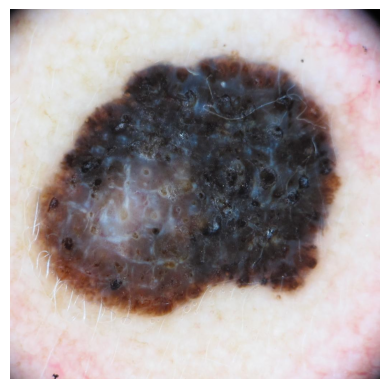

In [ ]:
# === BOTÓN PARA SUBIR IMAGEN ===
uploaded = files.upload()

# Obtener el nombre del archivo subido
img_path = list(uploaded.keys())[0]

# Cargar la imagen
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Mostrar la imagen para verificar
print("Imagen cargada",img.shape)
plt.imshow(img)
plt.axis("off")
plt.show()

Mascara binaria lista.


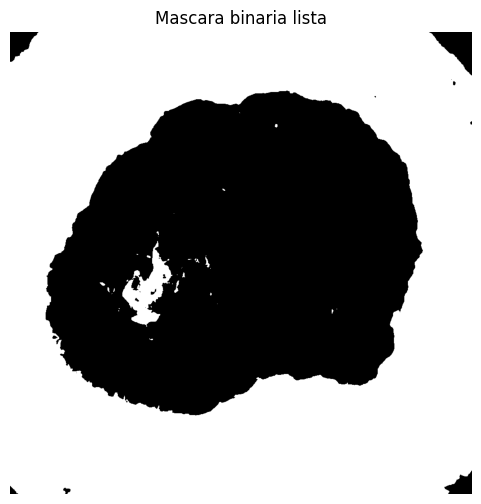

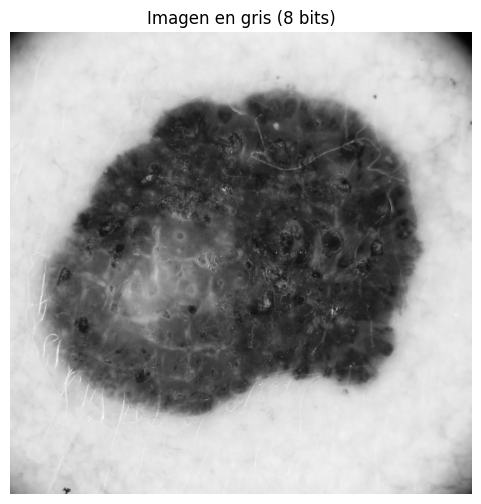

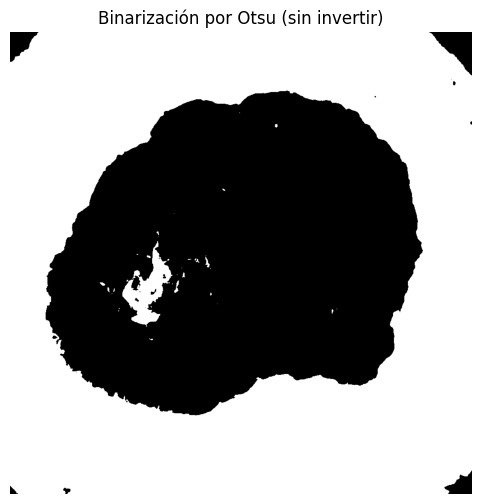

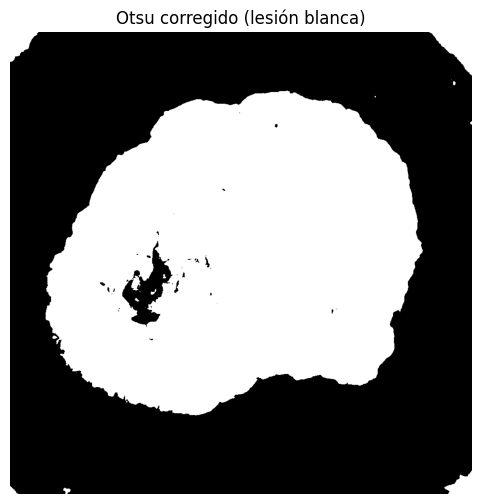

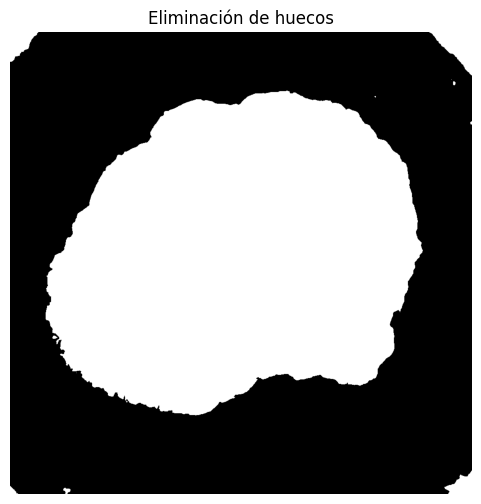

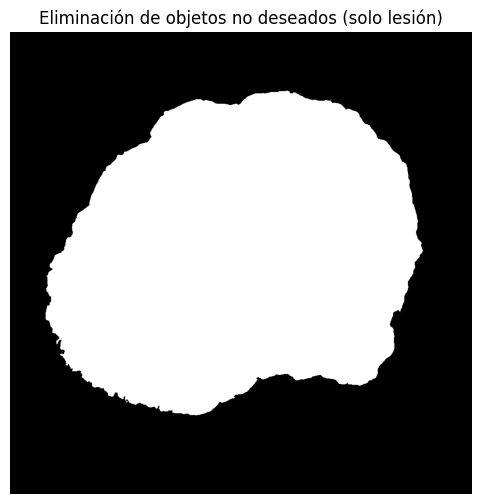

SEGMENTACIÓN COMPLETA 


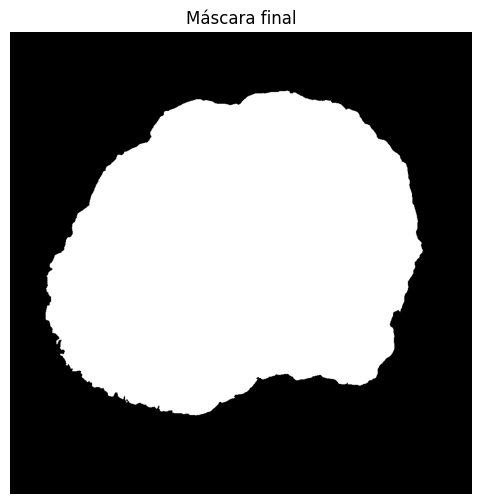

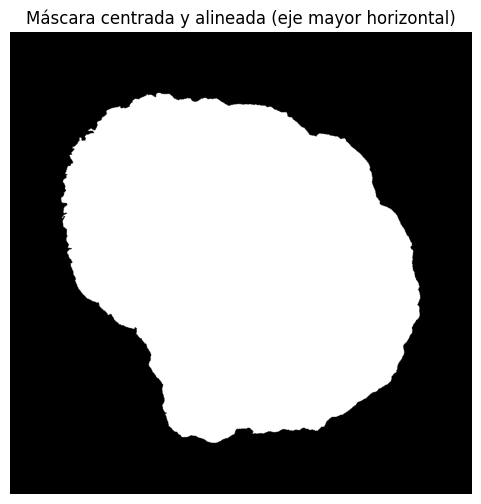

In [ ]:
# =======================================
# Segmentacion
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
blur = cv2.GaussianBlur(gray, (5,5), 0)
_, mask = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)

mask = (mask > 0).astype(np.uint8)

print("Mascara binaria lista.")
plt.figure(figsize=(6,6))
plt.title("Mascara binaria lista")
plt.imshow(mask*255, cmap="gray")
plt.axis("off")
plt.show()

# =======================================
# Conversión a escala de grises (8 bits)

gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

plt.figure(figsize=(6,6))
plt.title("Imagen en gris (8 bits)")
plt.imshow(gray, cmap="gray")
plt.axis("off")
plt.show()

# ========================================
# OTSU para binarizar

blur = cv2.GaussianBlur(gray, (5,5), 0)
_, otsu = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

plt.figure(figsize=(6,6))
plt.title("Binarización por Otsu (sin invertir)")
plt.imshow(otsu, cmap="gray")
plt.axis("off")
plt.show()

# ========================================
# Invertir

if otsu.mean() > 127:
    otsu = 255 - otsu

plt.figure(figsize=(6,6))
plt.title("Otsu corregido (lesión blanca)")
plt.imshow(otsu, cmap="gray")
plt.axis("off")
plt.show()

# ========================================
# Eliminar huecos interiores (fill holes)

mask_no_holes = binary_fill_holes(otsu > 0).astype(np.uint8) * 255

plt.figure(figsize=(6,6))
plt.title("Eliminación de huecos")
plt.imshow(mask_no_holes, cmap="gray")
plt.axis("off")
plt.show()

# ========================================
# Eliminar objetos pequeños / ruido (quedarse solo con la lesión principal)

    # etiquetar componentes conectados
num_labels, labels = cv2.connectedComponents(mask_no_holes)

    # medir tamaño de cada componente
areas = [(labels == i).sum() for i in range(1, num_labels)]

if len(areas) > 0:
    main_component = np.argmax(areas) + 1
    final_mask = (labels == main_component).astype(np.uint8) * 255
else:
    final_mask = mask_no_holes

plt.figure(figsize=(6,6))
plt.title("Eliminación de objetos no deseados (solo lesión)")
plt.imshow(final_mask, cmap="gray")
plt.axis("off")
plt.show()

# ========================================
# MÁSCARA FINAL

print("SEGMENTACIÓN COMPLETA ")

plt.figure(figsize=(6,6))
plt.title("Máscara final")
plt.imshow(final_mask, cmap="gray")
plt.axis("off")
plt.show()

# ========================================
# CENTRAR Y ROTAR SEGÚN EJE MAYOR

    # Encontrar contorno principal
contours, _ = cv2.findContours(final_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
if len(contours) > 0:
    contour = max(contours, key=lambda x: cv2.contourArea(x))

    # Ajustar elipse al contorno
    if len(contour) >= 5:  # cv2.fitEllipse requiere al menos 5 puntos
        ellipse = cv2.fitEllipse(contour)
        (Cx, Cy), (MA, ma), angle = ellipse

        # Rotar la máscara para que el eje mayor quede horizontal
        (h, w) = final_mask.shape
        rotation_matrix = cv2.getRotationMatrix2D(center=(Cx, Cy), angle=-angle, scale=1.0)
        mask_rotada = cv2.warpAffine(final_mask, rotation_matrix, (w, h), flags=cv2.INTER_NEAREST)

        # Trasladas para centrar el centroide en la imagen
        centro_img = (w//2, h//2)
        shift_x = int(centro_img[0] - Cx)
        shift_y = int(centro_img[1] - Cy)
        translation_matrix = np.float32([[1, 0, shift_x], [0, 1, shift_y]])
        final_mask_rotada = cv2.warpAffine(mask_rotada, translation_matrix, (w, h), flags=cv2.INTER_NEAREST)

    else:
        # Si no hay suficientes puntos, no rotamos
        final_mask_rotada = final_mask.copy()
else:
    final_mask_rotada = final_mask.copy()

# Mostrar máscara rotada
plt.figure(figsize=(6,6))
plt.title("Máscara centrada y alineada (eje mayor horizontal)")
plt.imshow(final_mask_rotada, cmap="gray")
plt.axis("off")
plt.show()

#POR FUNCIONES DEFINIDAS

##Funciones

In [ ]:
def tratado_imagen(img):
  #Segmentación
  gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
  blur = cv2.GaussianBlur(gray, (5,5), 0)
  _, mask = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)

  mask = (mask > 0).astype(np.uint8)
  mask=mask*255

  # Conversión a escala de grises (8 bits)

  gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

  # OTSU para binarizar

  blur = cv2.GaussianBlur(gray, (5,5), 0)
  _, otsu = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

  # Invertir

  if otsu.mean() > 127:
      otsu = 255 - otsu

  # Eliminar huecos interiores (fill holes)

  mask_no_holes = binary_fill_holes(otsu > 0).astype(np.uint8) * 255

  # Eliminar objetos pequeños / ruido (quedarse solo con la lesión principal)

      # etiquetar componentes conectados
  num_labels, labels = cv2.connectedComponents(mask_no_holes)

      # medir tamaño de cada componente
  areas = [(labels == i).sum() for i in range(1, num_labels)]

  if len(areas) > 0:
      main_component = np.argmax(areas) + 1
      final_mask = (labels == main_component).astype(np.uint8) * 255
  else:
      final_mask = mask_no_holes

  # CENTRAR Y ROTAR SEGÚN EJE MAYOR

      # Encontrar contorno principal
  contours, _ = cv2.findContours(final_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
  if len(contours) > 0:
      contour = max(contours, key=lambda x: cv2.contourArea(x))

      # Ajustar elipse al contorno
      if len(contour) >= 5:  # cv2.fitEllipse requiere al menos 5 puntos
          ellipse = cv2.fitEllipse(contour)
          (Cx, Cy), (MA, ma), angle = ellipse

           # Rotar la máscara para que el eje mayor quede horizontal
          (h, w) = final_mask.shape
          rotation_matrix = cv2.getRotationMatrix2D(center=(Cx, Cy), angle=-angle, scale=1.0)
          mask_rotada = cv2.warpAffine(final_mask, rotation_matrix, (w, h), flags=cv2.INTER_NEAREST)

          # Trasladas para centrar el centroide en la imagen
          centro_img = (w//2, h//2)
          shift_x = int(centro_img[0] - Cx)
          shift_y = int(centro_img[1] - Cy)
          translation_matrix = np.float32([[1, 0, shift_x], [0, 1, shift_y]])
          final_mask_rotada = cv2.warpAffine(mask_rotada, translation_matrix, (w, h), flags=cv2.INTER_NEAREST)

      else:
        # Si no hay suficientes puntos, no rotamos
        final_mask_rotada = final_mask.copy()
  else:
    final_mask_rotada = final_mask.copy()

  # return final_mask_rotada, final_mask, img, mask
  return {
    "img": img,
    "mask": mask,
    "gray": gray,
    "otsu": otsu,
    "mask_no_holes": mask_no_holes,
    "final_mask": final_mask,
    "final_mask_rotada": final_mask_rotada
  }

In [ ]:
def visualizacion(r):
    plt.figure(figsize=(14,6))

    plt.subplot(2,4,1)
    plt.imshow(r["img"])
    plt.title("Imagen original")
    plt.axis("off")

    plt.subplot(2,4,2)
    plt.imshow(r["gray"], cmap="gray")
    plt.title("Imagen en gris (8 bits)")
    plt.axis("off")

    plt.subplot(2,4,3)
    plt.imshow(r["mask"], cmap="gray")
    plt.title("Máscara binaria")
    plt.axis("off")

    plt.subplot(2,4,4)
    plt.imshow(r["otsu"], cmap="gray")
    plt.title("Binarización por Otsu invertida")
    plt.axis("off")

    plt.subplot(2,4,5)
    plt.imshow(r["mask_no_holes"], cmap="gray")
    plt.title("Eliminación de huecos")
    plt.axis("off")

    plt.subplot(2,4,6)
    plt.title("Eliminación de objetos no deseados")
    plt.imshow(final_mask, cmap="gray")
    plt.axis("off")

    plt.subplot(2,4,7)
    plt.imshow(r["final_mask"], cmap="gray")
    plt.title("Lesión principal")
    plt.axis("off")

    plt.subplot(2,4,8)
    plt.imshow(r["final_mask_rotada"], cmap="gray")
    plt.title("Máscara final centrada y alineada")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
def obtener_asimetria():
    # Bounding box
    mask = final_mask_rotada.copy()
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if len(contours) == 0:
        raise ValueError("No se encontraron contornos en la máscara.")

    contour = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(contour)

    # extraer ROI
    roi = mask[y:y+h, x:x+w]

    # centro del ROI
    cy, cx = h//2, w//2

    # dividir en cuadrantes
    q1 = roi[:cy, :cx]      # sup izq
    q2 = roi[:cy, cx:]      # sup der
    q3 = roi[cy:, :cx]      # inf izq
    q4 = roi[cy:, cx:]      # inf der

    # recortar al mínimo tamaño
    min_r = min(q1.shape[0], q2.shape[0], q3.shape[0], q4.shape[0])
    min_c = min(q1.shape[1], q2.shape[1], q3.shape[1], q4.shape[1])

    q1 = q1[:min_r, :min_c]
    q2 = q2[:min_r, :min_c]
    q3 = q3[:min_r, :min_c]
    q4 = q4[:min_r, :min_c]

    # Alinear cuadrantes sobre q1
    q2_flip = np.fliplr(q2)
    q3_flip = np.flipud(q3)
    q4_flip = np.flipud(np.fliplr(q4))

    #superponer
    superpos = q1 + q2_flip + q3_flip + q4_flip
    superpos = (superpos > 0).astype(np.uint8)

    # Índice Jaccard
    def jaccard_index(a, b):
        a = a.astype(bool)
        b = b.astype(bool)
        inter = np.logical_and(a,b).sum()
        union = np.logical_or(a,b).sum()
        return inter / (union + 1e-9)

    # comparar superposición con q1 para medir asimetría global
    IA_forma = 1 - jaccard_index(q1, superpos)
    asim_forma = IA_forma > 0.2

    # Mostrar ROI con bounding box
    mask_box = cv2.cvtColor(mask, cv2.COLOR_GRAY2RGB)
    cv2.rectangle(mask_box, (x, y), (x+w, y+h), (255,0,0), 2)

    return asim_forma, IA_forma, mask_box

In [ ]:
def obtener_bordes(final_mask_rotada):
  # Calcular índice de irregularidad de bordes

  # encontrar contorno principal
  contours, _ = cv2.findContours(final_mask_rotada, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
  if len(contours) == 0:
      raise ValueError("No se encontraron contornos en la máscara.")

  contour = max(contours, key=cv2.contourArea)

  # calcular área y perímetro
  area = cv2.contourArea(contour)
  perimeter = cv2.arcLength(contour, True)

  # índice de irregularidad
  I = (perimeter ** 2) / (4 * np.pi * area)

    # Interpretación según el valor de I
  if I <= 1.1:
      interpretacion_I = "Borde muy regular"
  elif I <= 1.3:
      interpretacion_I = "Borde moderadamente irregular"
  else:
      interpretacion_I = "Borde irregular"

  # Compactibilidad (C = P^2 / 4πA)
  def compactibilidad(mask):
      mask = mask.astype(np.uint8)
      # área
      area = np.sum(mask > 0)
      # perímetro
      contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
      if len(contours) == 0 or area == 0:
          return 0.0
      perimeter = cv2.arcLength(contours[0], True)
      C = (perimeter ** 2) / (4 * np.pi * area)
      return C

  # Resultado de C
  C_borde = compactibilidad(final_mask_rotada)

  # Interpretación según el valor de C
  if C_borde <= 1.1:
      interpretacion_C = "Borde muy regular"
  else:
      interpretacion_C = "Borde irregular"

  # return I, interpretacion_I, perimeter, area, interpretacion_C, C_borde
  return {
      "I": I,
      "interpretacion_I": interpretacion_I,
      "perimeter": perimeter,
      "area": area,
      "C_borde": C_borde,
      "interpretacion_C": interpretacion_C
  }


In [ ]:
COLORES_RELEVANTES = {
    "rojo":      [(0, 10, 50, 255, 50, 255), (160, 179, 50, 255, 50, 255)],
    "naranja":   [(11, 25, 50, 255, 50, 255)],
    "marron":    [(10, 20, 50, 255, 30, 150)],
    "negro":     [(0, 179, 0, 255, 0, 50)],
    "blanco":    [(0, 179, 0, 30, 200, 255)],
    "azul":      [(90, 130, 50, 255, 50, 255)]
}
def obtener_color(img, final_mask, colores=COLORES_RELEVANTES):
    # aplicar máscara (fondo negro)
    lesion = cv2.bitwise_and(img, img, mask=final_mask.astype(np.uint8))

    # convertir a HSV
    hsv = cv2.cvtColor(lesion, cv2.COLOR_BGR2HSV)

    # poner fondo a NaN
    lesion_float = lesion.astype(np.float32)
    lesion_float[final_mask == 0] = np.nan

    # contar pixeles de cada color
    colores_presentes = {}

    for color_name, rangos in colores.items():
        contador_total = 0
        for rango in rangos:
            Hmin,Hmax,Smin,Smax,Vmin,Vmax = rango
            # crear máscara para ese rango
            m = cv2.inRange(hsv, np.array([Hmin,Smin,Vmin]), np.array([Hmax,Smax,Vmax]))
            contador_total += cv2.countNonZero(m)
        if contador_total > 0:
            colores_presentes[color_name] = contador_total

    cantidad_colores_presentes = len(colores_presentes)

    return {
      "cantidad_colores": cantidad_colores_presentes,
      "colores_presentes": colores_presentes,
      "lesion": lesion,
      # "cantidad_colores_presentes": cantidad_colores_presentes
    }
    # return cantidad_colores, cantidad_colores_presentes, colores_presentes, lesion

In [ ]:
def obtener_diametro(mask):
    """
    Calcula el diámetro máximo de una lesión binarizada.
    mask: máscara binaria de la lesión (0 y 255)
    Devuelve: diámetro máximo en píxeles
    """
    # Asegurar máscara como uint8
    mask = mask.astype(np.uint8)

    # Encontrar contornos
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)

    if len(contours) == 0:
        return 0  # No hay lesión

    # Tomar el contorno más grande (la lesión principal)
    contour = max(contours, key=lambda x: cv2.contourArea(x))

    # Obtener todos los puntos del contorno
    points = contour[:, 0, :]  # shape (N,2)

    # Calcular la distancia máxima entre todos los pares de puntos
    max_dist = 0
    for i in range(len(points)):
        # Distancia Euclidiana a todos los puntos siguientes
        dists = np.linalg.norm(points[i+1:] - points[i], axis=1)
        if len(dists) > 0:
            max_dist = max(max_dist, dists.max())

    return max_dist

In [ ]:
# ============================================
#              FEATURES GLCM
# ============================================

def glcm_features(img, final_mask):
    img_gray = rgb2gray(img)
    img_gray = (img_gray * 255).astype(np.uint8)

    img_masked = img_gray.copy()
    img_masked[final_mask == 0] = 0

    distances = [1]
    angles = [0, np.pi/4, np.pi/2, 3*np.pi/4]

    glcm = graycomatrix(img_masked,
                        distances=distances,
                        angles=angles,
                        symmetric=True,
                        normed=True)

    feats = {
        'contrast': float(np.mean(graycoprops(glcm, 'contrast'))),
        'dissimilarity': float(np.mean(graycoprops(glcm, 'dissimilarity'))),
        'homogeneity': float(np.mean(graycoprops(glcm, 'homogeneity'))),
        'ASM': float(np.mean(graycoprops(glcm, 'ASM'))),
        'energy': float(np.mean(graycoprops(glcm, 'energy'))),
        'correlation': float(np.mean(graycoprops(glcm, 'correlation')))
    }
    return feats

# ============================================
#              FEATURES LAWS
# ============================================
def laws_features(img, final_mask):
    img_gray = rgb2gray(img)
    img_gray = (img_gray * 255).astype(np.float32)
    img_gray[final_mask == 0] = 0

    L5 = np.array([1, 4, 6, 4, 1])
    E5 = np.array([-1, -2,  0,  2,  1])
    S5 = np.array([-1,  0,  2,  0, -1])
    R5 = np.array([1, -4,  6, -4,  1])

    kernels = {
        'L5E5': np.outer(L5, E5),
        'E5L5': np.outer(E5, L5),
        'E5S5': np.outer(E5, S5),
        'S5E5': np.outer(S5, E5),
        'S5S5': np.outer(S5, S5),
        'R5R5': np.outer(R5, R5)
    }

    feats = {}
    maps = {}

    for name, ker in kernels.items():
        conv = convolve2d(img_gray, ker, mode='same')
        conv[final_mask == 0] = np.nan
        feats[name] = float(np.nanmean(np.abs(conv)))
        maps[name] = conv

    return feats, maps

# ============================================
#     DIMENSIÓN FRACTAL (BOX COUNTING)
# ============================================
def fractal_dimension(final_mask):

    Z = (final_mask > 0).astype(np.uint8)

    def boxcount(Z, k):
        S = np.add.reduceat(np.add.reduceat(Z,
                                            np.arange(0, Z.shape[0], k), axis=0),
                            np.arange(0, Z.shape[1], k), axis=1)
        return np.count_nonzero((S > 0) & (S < k*k))

    p = min(Z.shape)
    sizes = 2**np.arange(int(np.log2(p)), 1, -1)
    counts = [boxcount(Z, size) for size in sizes]

    coeffs = np.polyfit(np.log(sizes), np.log(counts), 1)
    return -coeffs[0]

In [ ]:
# ============================================================
#       DETECCIÓN DE ZONA ATÍPICA (Laws simplificado)
# ============================================================

def detect_atypical_area(lesion, mask):
    gray = cv2.cvtColor(lesion, cv2.COLOR_BGR2GRAY)

    L5 = np.array([1,4,6,4,1])
    E5 = np.array([-1,-2,0,2,1])
    S5 = np.array([-1,0,2,0,-1])

    filters = [
        np.outer(L5,E5),
        np.outer(E5,S5),
        np.outer(S5,E5),
        np.outer(E5,E5),
        np.outer(S5,S5)
    ]

    energy_maps = []
    for f in filters:
        resp = cv2.filter2D(gray, -1, f)
        energy_maps.append(resp.astype(np.float32)**2)

    heatmap = np.mean(energy_maps, axis=0)
    masked_heat = heatmap * (mask.astype(bool))

    vals = masked_heat[mask.astype(bool)]
    mu, sigma = np.mean(vals), np.std(vals)
    threshold = mu + 1.2*sigma

    zone = (masked_heat >= threshold).astype(np.uint8) * 255

    return heatmap, masked_heat, zone, threshold, mu, sigma


def is_atypical_network(masked_heat, threshold):
    lesion_pixels = np.sum(masked_heat > 0)
    atyp_pixels   = np.sum(masked_heat >= threshold)
    ratio = atyp_pixels / max(lesion_pixels, 1)
    return ratio >= 0.10, ratio

In [ ]:
def obtener_at_networks(img, final_mask):
    """
    Ejecuta la extracción de características de la red pigmentaria:
    - GLCM
    - Laws
    - Dimensión fractal
    - Detección de zona atípica (simplificada)

    Devuelve todos los resultados en un diccionario.
    """

    # ============================================
    # GLCM
    # ============================================
    glcm_res = glcm_features(img, final_mask)

    # ============================================
    # LAWS
    # ============================================
    laws_res, laws_maps = laws_features(img, final_mask)

    # ============================================
    # DIMENSIÓN FRACTAL
    # ============================================
    fractal_res = fractal_dimension(final_mask)

    # ============================================
    # DETECCIÓN DE ZONA ATÍPICA
    # ============================================
    heatmap, masked_heat, zone, threshold, mu, sigma = detect_atypical_area(img, final_mask)
    is_atypical, atyp_ratio = is_atypical_network(masked_heat, threshold)

    # ============================================
    # RETORNAR TODOS LOS RESULTADOS
    # ============================================
    return {
        "glcm": glcm_res,
        "laws": laws_res,
        "laws_maps": laws_maps,
        "fractal": fractal_res,
        "heatmap": heatmap,
        "masked_heat": masked_heat,
        "zone": zone,
        "threshold": threshold,
        "mu": mu,
        "sigma": sigma,
        "is_atypical": is_atypical,
        "atyp_ratio": atyp_ratio
    }

In [ ]:
def interpretacion_AN(res_networks):
    """
    Genera un texto interpretativo de los resultados de la red pigmentaria
    a partir del diccionario devuelto por obtener_at_networks().
    """
    txt = ""

    glcm_res = res_networks["glcm"]
    laws_res = res_networks["laws"]
    fractal_res = res_networks["fractal"]
    is_atypical = res_networks["is_atypical"]

    # Interpretación GLCM
    txt += "Contraste GLCM: {:.2f}. ".format(glcm_res['contrast'])
    if glcm_res['contrast'] > 50:
        txt += "Esto indica alta irregularidad en la red pigmentaria. "
    else:
        txt += "Esto indica una red más homogénea y típica. "

    # Interpretación Laws
    txt += "\nLaws E5S5: {:.2f}. ".format(laws_res['E5S5'])
    if laws_res['E5S5'] > 20:
        txt += "Sugiere texturas irregulares compatibles con red atípica. "
    else:
        txt += "No se observan patrones complejos significativos. "

    # Interpretación fractal
    txt += "\nDimensión fractal: {:.2f}. ".format(fractal_res)
    if fractal_res > 1.4:
        txt += "La complejidad del borde es elevada (mayor irregularidad). "
    else:
        txt += "El borde tiene una complejidad baja a moderada. "

    # Conclusión final
    txt += "\n\nConclusión final: "
    if is_atypical:
        txt += "La lesión cumple criterios para una red pigmentaria ATÍPICA."
    else:
        txt += "La lesión NO muestra criterios suficientes de red pigmentaria atípica."

    return txt

##Aplicacion de funciones

Saving ISIC_0072582.jpg to ISIC_0072582 (1).jpg


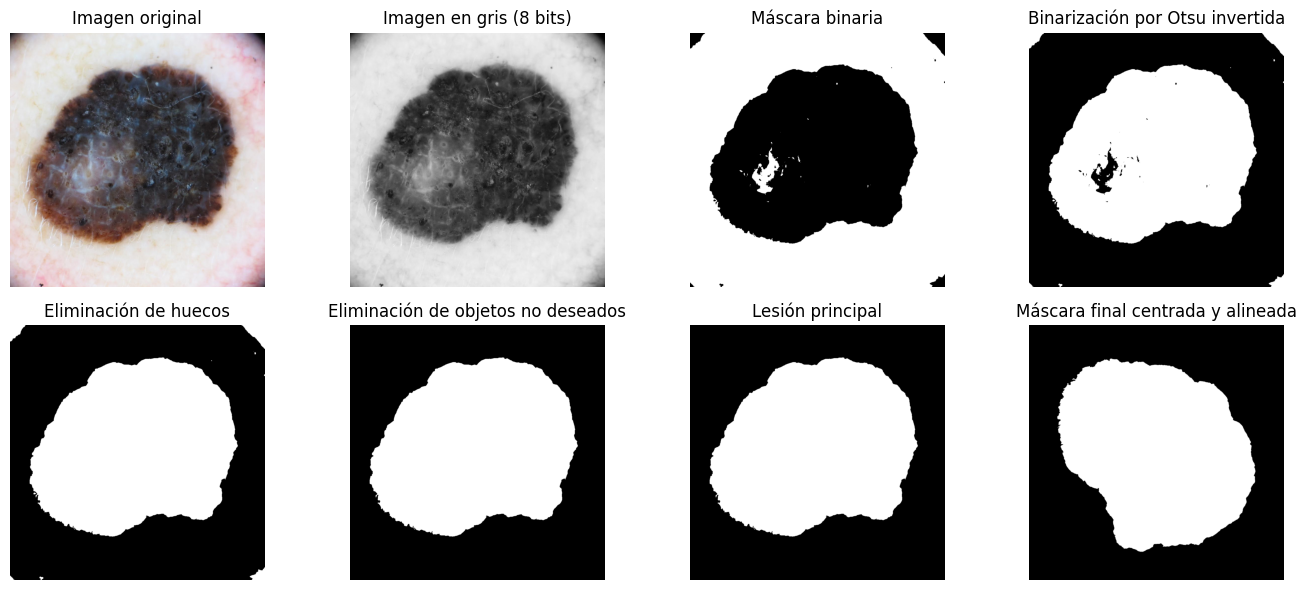

In [ ]:
# Subir imagen
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# Leer imagen
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Ejecutar función
resultados = tratado_imagen(img)
visualizacion(resultados)

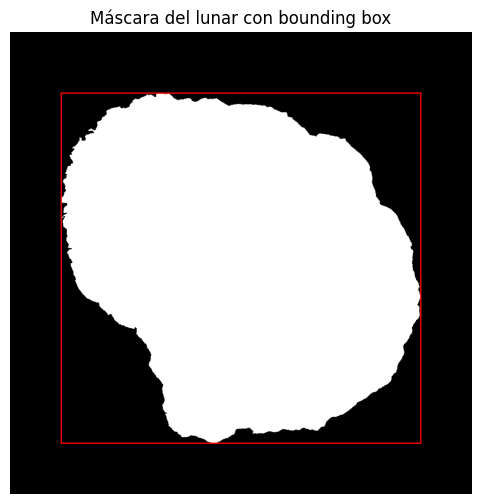

=== ASIMETRÍA DE FORMA ===
Asimétrica: False
Índice IA (forma): 0.0143


In [ ]:
asim_forma, IA_forma, mask_box= obtener_asimetria()
plt.figure(figsize=(6,6))
plt.imshow(mask_box)
plt.title("Máscara del lunar con bounding box")
plt.axis("off")
plt.show()

print("=== ASIMETRÍA DE FORMA ===")
print("Asimétrica:", asim_forma)
print("Índice IA (forma):", round(IA_forma,4)) #Mayor a 0.2 se considera asimetrica

In [ ]:
res = obtener_bordes(final_mask_rotada)

print("=== BORDES / IRREGULARIDAD ===")
print("Perímetro:", round(res["perimeter"], 2))
print("Área:", round(res["area"], 2))
print("Índice de irregularidad I:", round(res["I"], 4))
print("Interpretación:", res["interpretacion_I"])

print("=== DESCRIPTORES DE BORDE ===")
print("Compactibilidad (C):", round(res["C_borde"], 4))
print("Interpretación(C):", res["interpretacion_C"])

=== BORDES / IRREGULARIDAD ===
Perímetro: 3219.04
Área: 446671.5
Índice de irregularidad I: 1.8461
Interpretación: Borde irregular
=== DESCRIPTORES DE BORDE ===
Compactibilidad (C): 1.8405
Interpretación(C): Borde irregular


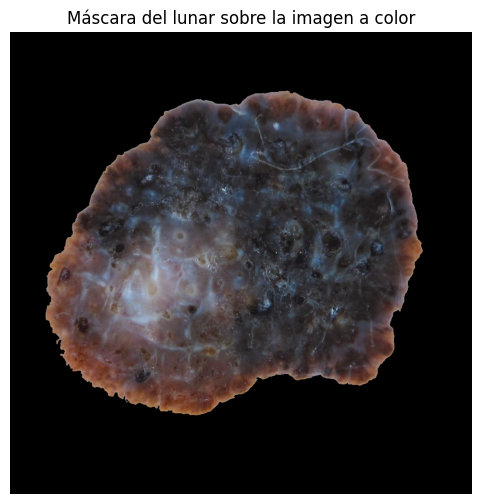

=== INDICADOR C (COLOR) ===
Cantidad de colores presentes: 6
Colores presentes y sus pixeles: {'rojo': 20025, 'naranja': 28113, 'marron': 29902, 'negro': 680615, 'blanco': 33, 'azul': 116598}


In [ ]:
res_color = obtener_color(img, final_mask)  # img en BGR

# mostrar imagen final: fondo negro, lunar a color
plt.figure(figsize=(6,6))
plt.imshow(res_color["lesion"])
plt.title("Máscara del lunar sobre la imagen a color")
plt.axis("off")
plt.show()

print("=== INDICADOR C (COLOR) ===")
print("Cantidad de colores presentes:", res_color["cantidad_colores"])
print("Colores presentes y sus pixeles:", res_color["colores_presentes"])

In [ ]:
# =========================
# USO
# =========================
diametro = obtener_diametro(final_mask)
print("DIÁMETRO MÁXIMO")
print(f"Diámetro máximo (píxeles): {diametro:.2f}")

DIÁMETRO MÁXIMO
Diámetro máximo (píxeles): 875.03


Contraste GLCM: 53.73. Esto indica alta irregularidad en la red pigmentaria. 
Laws E5S5: 27.50. Sugiere texturas irregulares compatibles con red atípica. 
Dimensión fractal: 1.12. El borde tiene una complejidad baja a moderada. 

Conclusión final: La lesión cumple criterios para una red pigmentaria ATÍPICA.


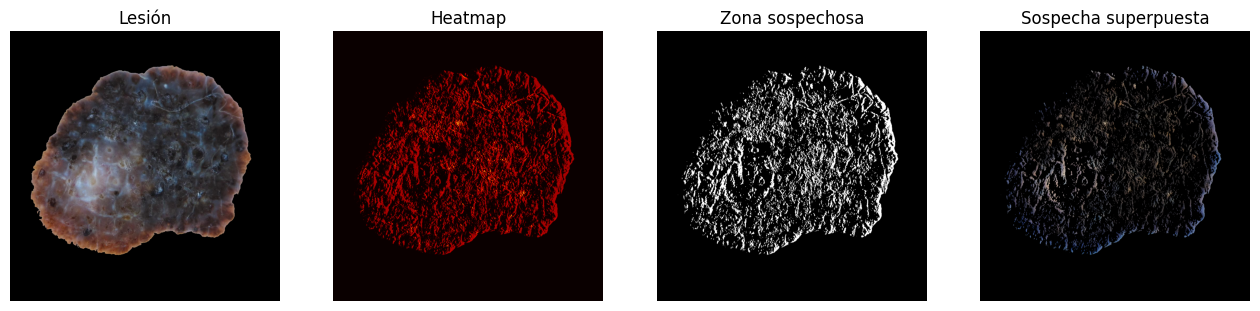

In [ ]:
from contextlib import redirect_stderr
# 1) Obtener todos los features
res_networks = obtener_at_networks(img, final_mask)

# 2) Obtener la interpretación en texto
texto_interpretacion = interpretacion_AN(res_networks)

# 3) Mostrar
print(texto_interpretacion)

plt.figure(figsize=(16,6))
plt.subplot(1,4,1); plt.title("Lesión"); plt.imshow(res_color["lesion"]); plt.axis("off")
plt.subplot(1,4,2); plt.title("Heatmap"); plt.imshow(res_networks["masked_heat"], cmap='hot'); plt.axis("off")
plt.subplot(1,4,3); plt.title("Zona sospechosa"); plt.imshow(res_networks["zone"], cmap='gray'); plt.axis("off")
plt.subplot(1,4,4); plt.title("Sospecha superpuesta")
masked = cv2.bitwise_and(res_color["lesion"], res_color["lesion"], mask=res_networks["zone"].astype(np.uint8))
plt.imshow(cv2.cvtColor(masked, cv2.COLOR_BGR2RGB)); plt.axis("off")
plt.show()

#ASIMETRIA

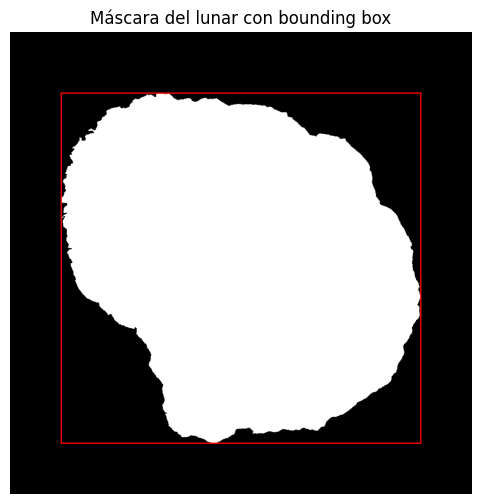

=== ASIMETRÍA DE FORMA ===
Asimétrica: False
Índice IA (forma, 0=casi simétrica, 1=muy asimétrica): 0.0143


In [ ]:
# ===========================
# 1) Bounding box
# ===========================
mask = final_mask_rotada.copy()
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
if len(contours) == 0:
    raise ValueError("No se encontraron contornos en la máscara.")

contour = max(contours, key=cv2.contourArea)
x, y, w, h = cv2.boundingRect(contour)

# extraer ROI
roi = mask[y:y+h, x:x+w]

# centro del ROI
cy, cx = h//2, w//2

# dividir en cuadrantes
q1 = roi[:cy, :cx]      # sup izq
q2 = roi[:cy, cx:]      # sup der
q3 = roi[cy:, :cx]      # inf izq
q4 = roi[cy:, cx:]      # inf der

# recortar al mínimo tamaño
min_r = min(q1.shape[0], q2.shape[0], q3.shape[0], q4.shape[0])
min_c = min(q1.shape[1], q2.shape[1], q3.shape[1], q4.shape[1])

q1 = q1[:min_r, :min_c]
q2 = q2[:min_r, :min_c]
q3 = q3[:min_r, :min_c]
q4 = q4[:min_r, :min_c]

# ===========================
# 2) Alinear cuadrantes sobre q1
# ===========================
q2_flip = np.fliplr(q2)      # voltear horizontal
q3_flip = np.flipud(q3)      # voltear vertical
q4_flip = np.flipud(np.fliplr(q4))  # voltear ambas

# superponer
superpos = q1 + q2_flip + q3_flip + q4_flip
superpos = (superpos > 0).astype(np.uint8)  # binarizar

# ===========================
# 3) Índice Jaccard
# ===========================
def jaccard_index(a, b):
    a = a.astype(bool)
    b = b.astype(bool)
    inter = np.logical_and(a,b).sum()
    union = np.logical_or(a,b).sum()
    return inter / (union + 1e-9)

# comparar superposición con q1 para medir asimetría global
IA_forma = 1 - jaccard_index(q1, superpos)
asim_forma = IA_forma > 0.2

# ===========================
# 4) Mostrar ROI con bounding box
# ===========================
mask_box = cv2.cvtColor(mask, cv2.COLOR_GRAY2RGB)
cv2.rectangle(mask_box, (x, y), (x+w, y+h), (255,0,0), 2)

plt.figure(figsize=(6,6))
plt.imshow(mask_box)
plt.title("Máscara del lunar con bounding box")
plt.axis("off")
plt.show()

print("=== ASIMETRÍA DE FORMA ===")
print("Asimétrica:", asim_forma)
print("Índice IA (forma, 0=casi simétrica, 1=muy asimétrica):", round(IA_forma,4))

#BORDES

In [ ]:
import cv2
import numpy as np

# ===========================
# Calcular índice de irregularidad de bordes
# ===========================

# encontrar contorno principal
contours, _ = cv2.findContours(final_mask_rotada, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
if len(contours) == 0:
    raise ValueError("No se encontraron contornos en la máscara.")

contour = max(contours, key=cv2.contourArea)

# calcular área y perímetro
area = cv2.contourArea(contour)
perimeter = cv2.arcLength(contour, True)

# índice de irregularidad
I = (perimeter ** 2) / (4 * np.pi * area)

# Interpretación según el valor de I
if I <= 1.1:
    interpretacion = "Borde muy regular"
elif I <= 1.3:
    interpretacion = "Borde moderadamente irregular"
else:
    interpretacion = "Borde irregular"

print("=== BORDES / IRREGULARIDAD ===")
print("Perímetro:", round(perimeter, 2))
print("Área:", round(area, 2))
print("Índice de irregularidad I:", round(I, 4))
print("Interpretación:", interpretacion)

=== BORDES / IRREGULARIDAD ===
Perímetro: 601.85
Área: 14467.5
Índice de irregularidad I: 1.9924
Interpretación: Borde irregular


In [ ]:
# ===========================
# 2. Compactibilidad (C = P^2 / 4πA)
# ===========================
def compactibilidad(mask):
    mask = mask.astype(np.uint8)
    # área
    area = np.sum(mask > 0)
    # perímetro
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if len(contours) == 0 or area == 0:
        return 0.0
    perimeter = cv2.arcLength(contours[0], True)
    C = (perimeter ** 2) / (4 * np.pi * area)
    return C

# ===========================
# RESULTADO
# ===========================
C_borde = compactibilidad(final_mask_rotada)

# Interpretación según el valor de C
if I <= 1.1:
    interpretacion = "Borde muy regular"
else:
    interpretacion = "Borde irregular"

print("=== DESCRIPTORES DE BORDE ===")
print("Compactibilidad (C):", round(C_borde, 4))
print("Interpretación(C):", interpretacion)

=== DESCRIPTORES DE BORDE ===
Compactibilidad (C): 1.958
Interpretación(C): Borde irregular


Compactibilidad
𝐶 = 𝑃^2 / 4𝜋𝐴

Este mide qué tan alejado está el contorno de un círculo perfecto.

Valores cercanos a 1 → borde muy regular (casi circular).

Valores más altos → borde más irregular.

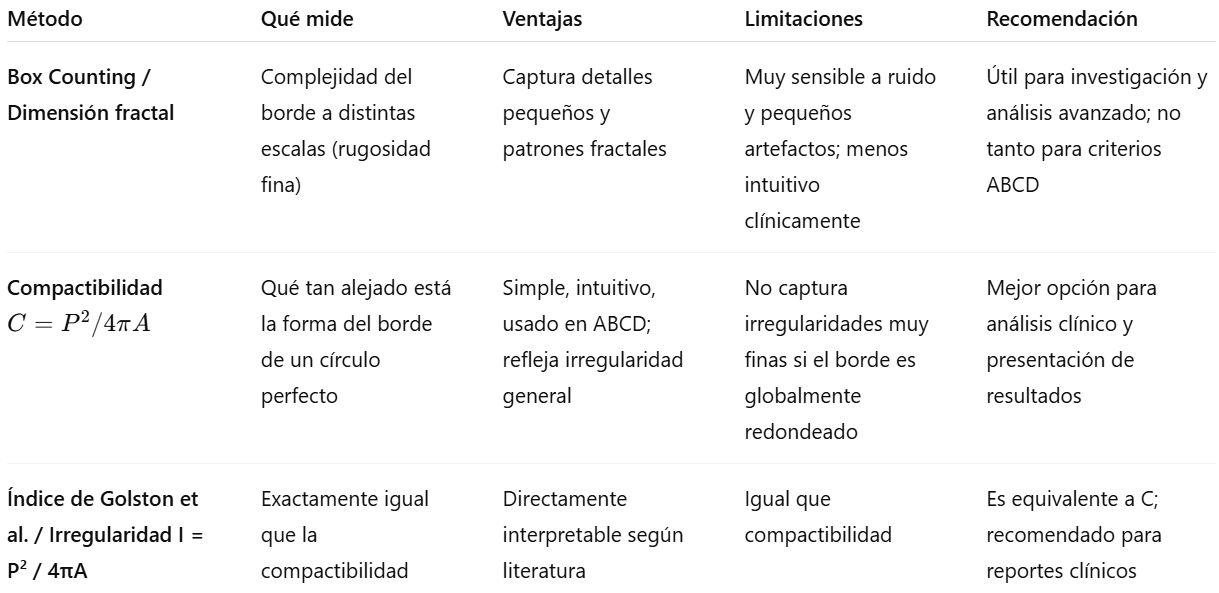

#COLOR

In [ ]:
final_mask_rotada.dtype #verifico que este en [0,255]
img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)  # convertir a BGR para OpenCV

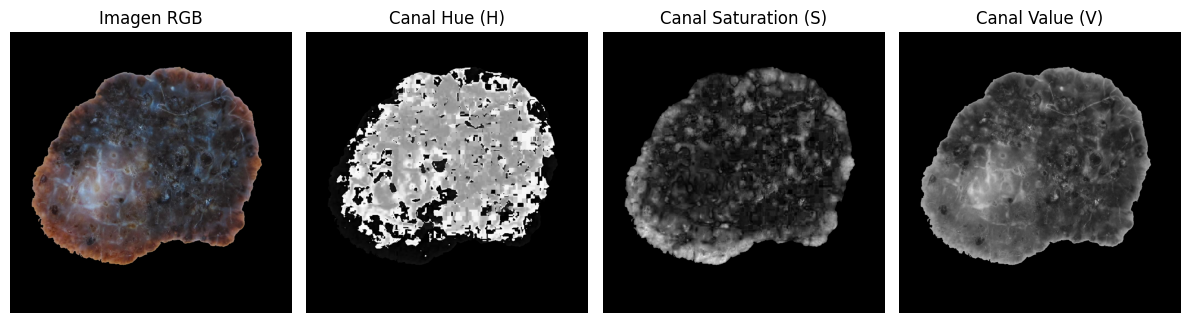

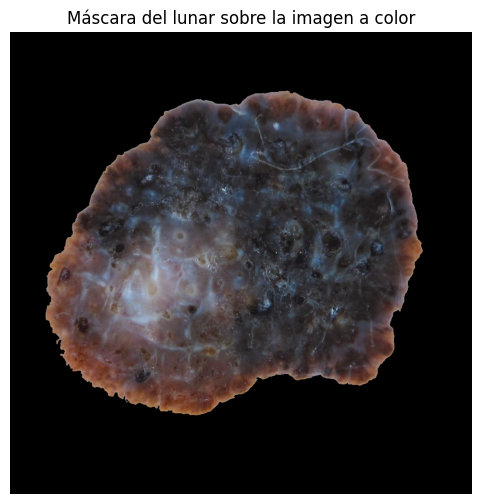

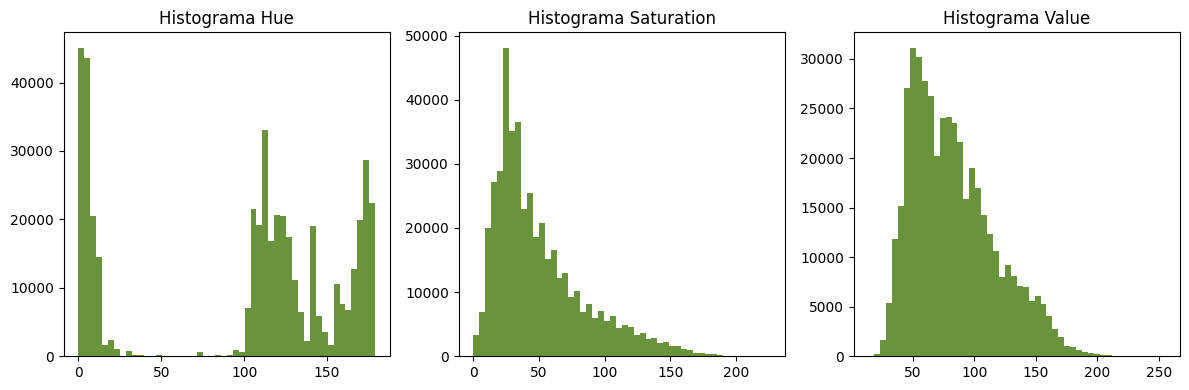

=== INDICADOR C (COLOR) ===
Cantidad de colores presentes: 6
Colores presentes y sus pixeles: {'rojo': 107181, 'naranja': 11512, 'marron': 10442, 'negro': 680615, 'blanco': 33, 'azul': 48059}


In [ ]:
# ===========================
# Definir colores relevantes
# Cada color tiene un rango HSV: (Hmin,Hmax,Smin,Smax,Vmin,Vmax)
# Valores de H: 0-179 en OpenCV, S y V: 0-255
colores_relevantes = {
    "rojo":      [(0, 10, 50, 255, 50, 255), (160, 179, 50, 255, 50, 255)],  # rojo puede tener dos rangos de H
    "naranja":   [(11, 25, 50, 255, 50, 255)],
    "marron":    [(10, 20, 50, 255, 30, 150)],
    "negro":     [(0, 179, 0, 255, 0, 50)],
    "blanco":    [(0, 179, 0, 30, 200, 255)],
    "azul":      [(90, 130, 50, 255, 50, 255)]
}

# ===========================
# Calcular indicador C (color)
# ===========================
def indicador_color(image, mask, colores=colores_relevantes):
    """
    image: imagen original RGB o BGR
    mask: máscara binaria de la lesión (0,255)
    colores: diccionario con rangos HSV de colores relevantes
    """
    # aplicar máscara (fondo negro)
    lesion = cv2.bitwise_and(image, image, mask=mask.astype(np.uint8))

    # convertir a HSV
    hsv = cv2.cvtColor(lesion, cv2.COLOR_BGR2HSV)

    # ===========================
    # SUBPLOT: RGB + H + S + V
    # ===========================

    H, S, V = cv2.split(hsv)

    plt.figure(figsize=(12,4))

    plt.subplot(1,4,1)
    plt.imshow(cv2.cvtColor(lesion, cv2.COLOR_BGR2RGB))
    plt.title("Imagen RGB")
    plt.axis("off")

    plt.subplot(1,4,2)
    plt.imshow(H, cmap="gray")
    plt.title("Canal Hue (H)")
    plt.axis("off")

    plt.subplot(1,4,3)
    plt.imshow(S, cmap="gray")
    plt.title("Canal Saturation (S)")
    plt.axis("off")

    plt.subplot(1,4,4)
    plt.imshow(V, cmap="gray")
    plt.title("Canal Value (V)")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    # poner fondo a NaN
    lesion_float = lesion.astype(np.float32)
    lesion_float[mask == 0] = np.nan

    # contar pixeles de cada color
    colores_presentes = {}

    for color_name, rangos in colores.items():
        contador_total = 0
        for rango in rangos:
            Hmin,Hmax,Smin,Smax,Vmin,Vmax = rango
            # crear máscara para ese rango
            m = cv2.inRange(hsv, np.array([Hmin,Smin,Vmin]), np.array([Hmax,Smax,Vmax]))
            contador_total += cv2.countNonZero(m)
        if contador_total > 0:
            colores_presentes[color_name] = contador_total

    cantidad_colores_presentes = len(colores_presentes)

    # mostrar imagen final: fondo negro, lunar a color
    plt.figure(figsize=(6,6))
    plt.imshow(cv2.cvtColor(lesion, cv2.COLOR_BGR2RGB))
    plt.title("Máscara del lunar sobre la imagen a color")
    plt.axis("off")
    plt.show()

    # ===========================
    # HISTOGRAMAS HSV
    # ===========================

    # usar solo pixeles de la lesión
    H_vals = H[mask > 0]
    S_vals = S[mask > 0]
    V_vals = V[mask > 0]

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.hist(H_vals.ravel(), bins=50, color="#6a943c")
    plt.title("Histograma Hue")

    plt.subplot(1,3,2)
    plt.hist(S_vals.ravel(), bins=50, color="#6a943c")
    plt.title("Histograma Saturation")

    plt.subplot(1,3,3)
    plt.hist(V_vals.ravel(), bins=50, color="#6a943c")
    plt.title("Histograma Value")

    plt.tight_layout()
    plt.show()

    return cantidad_colores_presentes, colores_presentes, lesion

# ===========================
# RESULTADO
# ===========================
cantidad_colores, colores_detalle, lesion = indicador_color(cv2.cvtColor(img, cv2.COLOR_BGR2RGB), final_mask)

print("=== INDICADOR C (COLOR) ===")
print("Cantidad de colores presentes:", cantidad_colores)
print("Colores presentes y sus pixeles:", colores_detalle)

#DIAMETRO

In [ ]:
def diametro_maximo(mask):
    """
    Calcula el diámetro máximo de una lesión binarizada.
    mask: máscara binaria de la lesión (0 y 255)
    Devuelve: diámetro máximo en píxeles
    """
    # Asegurar máscara como uint8
    mask = mask.astype(np.uint8)

    # Encontrar contornos
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)

    if len(contours) == 0:
        return 0  # No hay lesión

    # Tomar el contorno más grande (la lesión principal)
    contour = max(contours, key=lambda x: cv2.contourArea(x))

    # Obtener todos los puntos del contorno
    points = contour[:, 0, :]  # shape (N,2)

    # Calcular la distancia máxima entre todos los pares de puntos
    max_dist = 0
    for i in range(len(points)):
        # Distancia Euclidiana a todos los puntos siguientes
        dists = np.linalg.norm(points[i+1:] - points[i], axis=1)
        if len(dists) > 0:
            max_dist = max(max_dist, dists.max())

    return max_dist

# =========================
# USO
# =========================
diametro = diametro_maximo(final_mask)
print("=== DIÁMETRO MÁXIMO ===")
print(f"Diámetro máximo (píxeles): {diametro:.2f}")

=== DIÁMETRO MÁXIMO ===
Diámetro máximo (píxeles): 162.12


#Atypical Networks

In [ ]:
from skimage.feature import graycomatrix, graycoprops
from skimage.color import rgb2gray

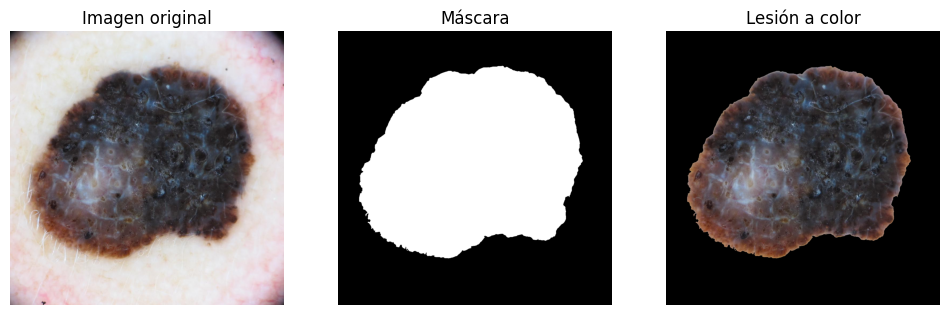

In [ ]:
# Mostrar imágenes
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.title("Imagen original"); plt.imshow(img); plt.axis('off')
plt.subplot(1,3,2); plt.title("Máscara"); plt.imshow(final_mask, cmap='gray'); plt.axis('off')
plt.subplot(1,3,3); plt.title("Lesión a color"); plt.imshow(cv2.cvtColor(lesion, cv2.COLOR_BGR2RGB)); plt.axis('off')
plt.show()

In [ ]:
# ============================================
#              FEATURES GLCM
# ============================================

def glcm_features(img, final_mask):
    img_gray = rgb2gray(img)
    img_gray = (img_gray * 255).astype(np.uint8)

    img_masked = img_gray.copy()
    img_masked[final_mask == 0] = 0

    distances = [1]
    angles = [0, np.pi/4, np.pi/2, 3*np.pi/4]

    glcm = graycomatrix(img_masked,
                        distances=distances,
                        angles=angles,
                        symmetric=True,
                        normed=True)

    feats = {
        'contrast': float(np.mean(graycoprops(glcm, 'contrast'))),
        'dissimilarity': float(np.mean(graycoprops(glcm, 'dissimilarity'))),
        'homogeneity': float(np.mean(graycoprops(glcm, 'homogeneity'))),
        'ASM': float(np.mean(graycoprops(glcm, 'ASM'))),
        'energy': float(np.mean(graycoprops(glcm, 'energy'))),
        'correlation': float(np.mean(graycoprops(glcm, 'correlation')))
    }
    return feats

# ============================================
#              FEATURES LAWS
# ============================================
def laws_features(img, final_mask):
    img_gray = rgb2gray(img)
    img_gray = (img_gray * 255).astype(np.float32)
    img_gray[final_mask == 0] = 0

    L5 = np.array([1, 4, 6, 4, 1])
    E5 = np.array([-1, -2,  0,  2,  1])
    S5 = np.array([-1,  0,  2,  0, -1])
    R5 = np.array([1, -4,  6, -4,  1])

    kernels = {
        'L5E5': np.outer(L5, E5),
        'E5L5': np.outer(E5, L5),
        'E5S5': np.outer(E5, S5),
        'S5E5': np.outer(S5, E5),
        'S5S5': np.outer(S5, S5),
        'R5R5': np.outer(R5, R5)
    }

    feats = {}
    maps = {}

    for name, ker in kernels.items():
        conv = convolve2d(img_gray, ker, mode='same')
        conv[final_mask == 0] = np.nan
        feats[name] = float(np.nanmean(np.abs(conv)))
        maps[name] = conv

    return feats, maps

# ============================================
#     DIMENSIÓN FRACTAL (BOX COUNTING)
# ============================================
def fractal_dimension(final_mask):

    Z = (final_mask > 0).astype(np.uint8)

    def boxcount(Z, k):
        S = np.add.reduceat(np.add.reduceat(Z,
                                            np.arange(0, Z.shape[0], k), axis=0),
                            np.arange(0, Z.shape[1], k), axis=1)
        return np.count_nonzero((S > 0) & (S < k*k))

    p = min(Z.shape)
    sizes = 2**np.arange(int(np.log2(p)), 1, -1)
    counts = [boxcount(Z, size) for size in sizes]

    coeffs = np.polyfit(np.log(sizes), np.log(counts), 1)
    return -coeffs[0]

In [ ]:
# ============================================================
#       DETECCIÓN DE ZONA ATÍPICA (Laws simplificado)
# ============================================================

def detect_atypical_area(lesion, mask):
    gray = cv2.cvtColor(lesion, cv2.COLOR_BGR2GRAY)

    L5 = np.array([1,4,6,4,1])
    E5 = np.array([-1,-2,0,2,1])
    S5 = np.array([-1,0,2,0,-1])

    filters = [
        np.outer(L5,E5),
        np.outer(E5,S5),
        np.outer(S5,E5),
        np.outer(E5,E5),
        np.outer(S5,S5)
    ]

    energy_maps = []
    for f in filters:
        resp = cv2.filter2D(gray, -1, f)
        energy_maps.append(resp.astype(np.float32)**2)

    heatmap = np.mean(energy_maps, axis=0)
    masked_heat = heatmap * (mask.astype(bool))

    vals = masked_heat[mask.astype(bool)]
    mu, sigma = np.mean(vals), np.std(vals)
    threshold = mu + 1.2*sigma

    zone = (masked_heat >= threshold).astype(np.uint8) * 255

    return heatmap, masked_heat, zone, threshold, mu, sigma


def is_atypical_network(masked_heat, threshold):
    lesion_pixels = np.sum(masked_heat > 0)
    atyp_pixels   = np.sum(masked_heat >= threshold)
    ratio = atyp_pixels / max(lesion_pixels, 1)
    return ratio >= 0.10, ratio

In [ ]:
# ============================================================
#              EJECUCIÓN FINAL DE FEATURES
# ============================================================

glcm_res = glcm_features(img, final_mask)
laws_res, laws_maps = laws_features(img, final_mask)
fractal_res = fractal_dimension(final_mask)

print("\n===== GLCM =====")
for k, v in glcm_res.items():
    print(f"{k}: {v:.4f}")

print("\n===== LAWS =====")
for k, v in laws_res.items():
    print(f"{k}: {v:.4f}")

print("\n===== DIMENSIÓN FRACTAL =====")
print(f"D: {fractal_res:.4f}")


===== GLCM =====
contrast: 53.7262
dissimilarity: 1.8761
homogeneity: 0.6942
ASM: 0.3263
energy: 0.5712
correlation: 0.9827

===== LAWS =====
L5E5: 293.9600
E5L5: 283.8173
E5S5: 27.5036
S5E5: 26.5523
S5S5: 14.7269
R5R5: 46.6169

===== DIMENSIÓN FRACTAL =====
D: 1.1183


In [ ]:
# ============================================================
#     ÁREA ATÍPICA (NETWORK-LIKE STRUCTURE)
# ============================================================

heatmap, masked_heat, zone, thr, mu, sigma = detect_atypical_area(lesion, final_mask)
is_atypical, ratio = is_atypical_network(masked_heat, thr)

print("\n===== NETWORK ATÍPICO =====")
print("Atypical:", is_atypical)
print(f"Ratio energía alta: {ratio:.3f}")
print(f"Umbral = {thr:.2f} | μ = {mu:.2f} | σ = {sigma:.2f}")


===== NETWORK ATÍPICO =====
Atypical: True
Ratio energía alta: 0.223
Umbral = 12344.82 | μ = 4578.98 | σ = 6471.53


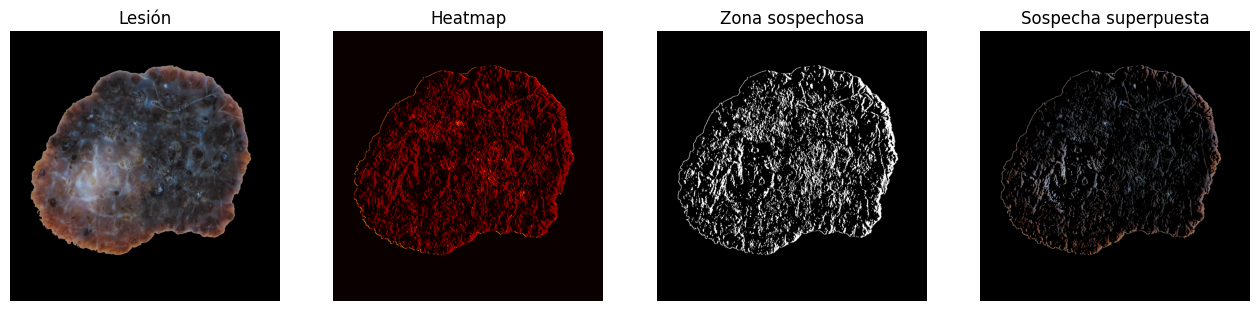

In [ ]:
# ============================================================
#                  VISUALIZACIÓN FINAL
# ============================================================

plt.figure(figsize=(16,6))
plt.subplot(1,4,1); plt.title("Lesión"); plt.imshow(cv2.cvtColor(lesion, cv2.COLOR_BGR2RGB)); plt.axis("off")
plt.subplot(1,4,2); plt.title("Heatmap"); plt.imshow(masked_heat, cmap='hot'); plt.axis("off")
plt.subplot(1,4,3); plt.title("Zona sospechosa"); plt.imshow(zone, cmap='gray'); plt.axis("off")
plt.subplot(1,4,4); plt.title("Sospecha superpuesta")
masked = cv2.bitwise_and(lesion, lesion, mask=zone.astype(np.uint8))
plt.imshow(cv2.cvtColor(masked, cv2.COLOR_BGR2RGB)); plt.axis("off")
plt.show()

In [ ]:
def interpretacion(glcm_res, laws_res, fractal_res, atypical):
    txt = ""

    txt += "Contraste GLCM: {:.2f}. ".format(glcm_res['contrast'])
    if glcm_res['contrast'] > 50:
        txt += "Esto indica alta irregularidad en la red pigmentaria. "
    else:
        txt += "Esto indica una red más homogénea y típica. "

    txt += "\nLaws E5S5: {:.2f}. ".format(laws_res['E5S5'])
    if laws_res['E5S5'] > 20:
        txt += "Sugiere texturas irregulares compatibles con red atípica. "
    else:
        txt += "No se observan patrones complejos significativos. "

    txt += "\nDimensión fractal: {:.2f}. ".format(fractal_res)
    if fractal_res > 1.4:
        txt += "La complejidad del borde es elevada (mayor irregularidad). "
    else:
        txt += "El borde tiene una complejidad baja a moderada. "

    txt += "\n\nConclusión final: "
    if is_atypical:
        txt += "La lesión cumple criterios para una red pigmentaria ATÍPICA."
    else:
        txt += "La lesión NO muestra criterios suficientes de red pigmentaria atípica."

    return txt

print(interpretacion(glcm_res, laws_res, fractal_res, is_atypical))

Contraste GLCM: 53.73. Esto indica alta irregularidad en la red pigmentaria. 
Laws E5S5: 27.50. Sugiere texturas irregulares compatibles con red atípica. 
Dimensión fractal: 1.12. El borde tiene una complejidad baja a moderada. 

Conclusión final: La lesión cumple criterios para una red pigmentaria ATÍPICA.
